In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import joblib
import shap
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve

def find_threshold_for_recall(model, X_val, y_val, target_recall=0.9):
    y_prob = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

    idx = np.where(recall >= target_recall)[0][-1]
    return thresholds[idx]



In [62]:
# Read csv files
df= pd.read_csv("mimiciii_icu_mortality_features_v1.csv")
df.head(10)


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,GCS_max,GCS_mean,Lactate_min,Lactate_max,Lactate_mean,BUN_min,BUN_mean,...,DIASBP_MEAN,AGE,RR_MEAN,RR_STD,RR_MAX,TEMP_STD,TEMP_MIN,HR_MEAN,HR_MAX,age_adj_comorbidity_score
0,3,145834,211552,6.0,4.444444,1.3,8.8,3.800000,36.0,40.500000,...,58.643678,76,17.137255,3.464215,29.0,0.335085,36.200001,98.925373,168.0,16.0
1,6,107064,228232,6.0,6.000000,NaN,NaN,NaN,65.0,65.500000,...,60.010417,65,12.937500,3.392145,22.0,0.441010,36.000002,84.791667,100.0,12.0
2,9,150750,220597,5.0,2.600000,1.9,2.7,2.380000,17.0,18.500000,...,76.731959,41,14.276316,0.917950,19.0,0.822093,35.500001,87.644737,111.0,12.0
3,12,112213,232669,6.0,4.842105,1.6,15.1,8.716667,28.0,35.500000,...,72.409302,72,15.944444,1.963676,23.0,0.837151,35.500001,83.208333,105.0,7.0
4,17,194023,277042,6.0,5.615385,0.9,0.9,0.900000,10.0,10.666667,...,52.360656,47,22.196429,5.753796,35.0,0.623295,36.000002,82.400000,114.0,0.0
5,21,109451,217847,6.0,6.000000,1.5,2.3,2.060000,50.0,77.666667,...,51.566434,87,16.222222,3.719742,26.0,0.459382,35.388887,71.690909,125.0,21.0
6,21,111970,216859,6.0,5.923077,1.6,2.7,2.150000,50.0,56.500000,...,39.214912,87,18.065574,3.749973,27.0,0.654310,35.944443,77.580645,100.0,20.0
7,25,129635,203487,6.0,6.000000,1.0,1.8,1.400000,34.0,46.333333,...,51.133333,58,18.172414,4.083076,36.0,0.528102,35.722224,76.898305,104.0,1.0
8,26,197661,244882,6.0,6.000000,NaN,NaN,NaN,28.0,29.500000,...,42.744681,72,20.106383,3.023344,26.0,0.453136,36.499998,70.404255,86.0,15.0
9,31,128652,254478,4.0,2.920000,1.4,1.5,1.450000,11.0,12.000000,...,54.560209,72,12.076923,0.269953,13.0,0.757767,35.000000,50.948718,57.0,18.0


In [63]:
# Find dataset size and column data types
print(df.shape)
pd.DataFrame({"column": df.columns, "dtype": df.dtypes.values})



(21178, 34)


,column,dtype
0,SUBJECT_ID,int64
1,HADM_ID,int64
2,ICUSTAY_ID,int64
3,GCS_max,float64
4,GCS_mean,float64
5,Lactate_min,float64
6,Lactate_max,float64
7,Lactate_mean,float64
8,BUN_min,float64
9,BUN_mean,float64


In [64]:
# Checking missing values
df.isnull().sum()

SUBJECT_ID                       0
HADM_ID                          0
ICUSTAY_ID                       0
GCS_max                        309
GCS_mean                       309
Lactate_min                   9328
Lactate_max                   9328
Lactate_mean                  9328
BUN_min                        171
BUN_mean                       171
AG_max                         282
AG_mean                        282
Bilirubin_max                11900
Bilirubin_mean               11900
MORTALITY_INHOSPITAL             0
AG_MEAN                        194
AG_MAX                         194
AG_MEDIAN                      194
AG_MIN                         194
AG_STD                         495
SYSBP_MIN                      250
SYSBP_MEAN                     250
SYSBP_STD                      252
DIASBP_MIN                     250
DIASBP_MEAN                    250
AGE                              0
RR_MEAN                        317
RR_STD                         323
RR_MAX              

In [65]:
# Checking missing value and value counts of Target varaible
print(df['MORTALITY_INHOSPITAL'].isnull().sum())
df['MORTALITY_INHOSPITAL'].value_counts()


0


MORTALITY_INHOSPITAL
0    18426
1     2752
Name: count, dtype: int64

In [66]:
# Print the all columns names
print(df.columns.tolist())

['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'GCS_max', 'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min', 'BUN_mean', 'AG_max', 'AG_mean', 'Bilirubin_max', 'Bilirubin_mean', 'MORTALITY_INHOSPITAL', 'AG_MEAN', 'AG_MAX', 'AG_MEDIAN', 'AG_MIN', 'AG_STD', 'SYSBP_MIN', 'SYSBP_MEAN', 'SYSBP_STD', 'DIASBP_MIN', 'DIASBP_MEAN', 'AGE', 'RR_MEAN', 'RR_STD', 'RR_MAX', 'TEMP_STD', 'TEMP_MIN', 'HR_MEAN', 'HR_MAX', 'age_adj_comorbidity_score']


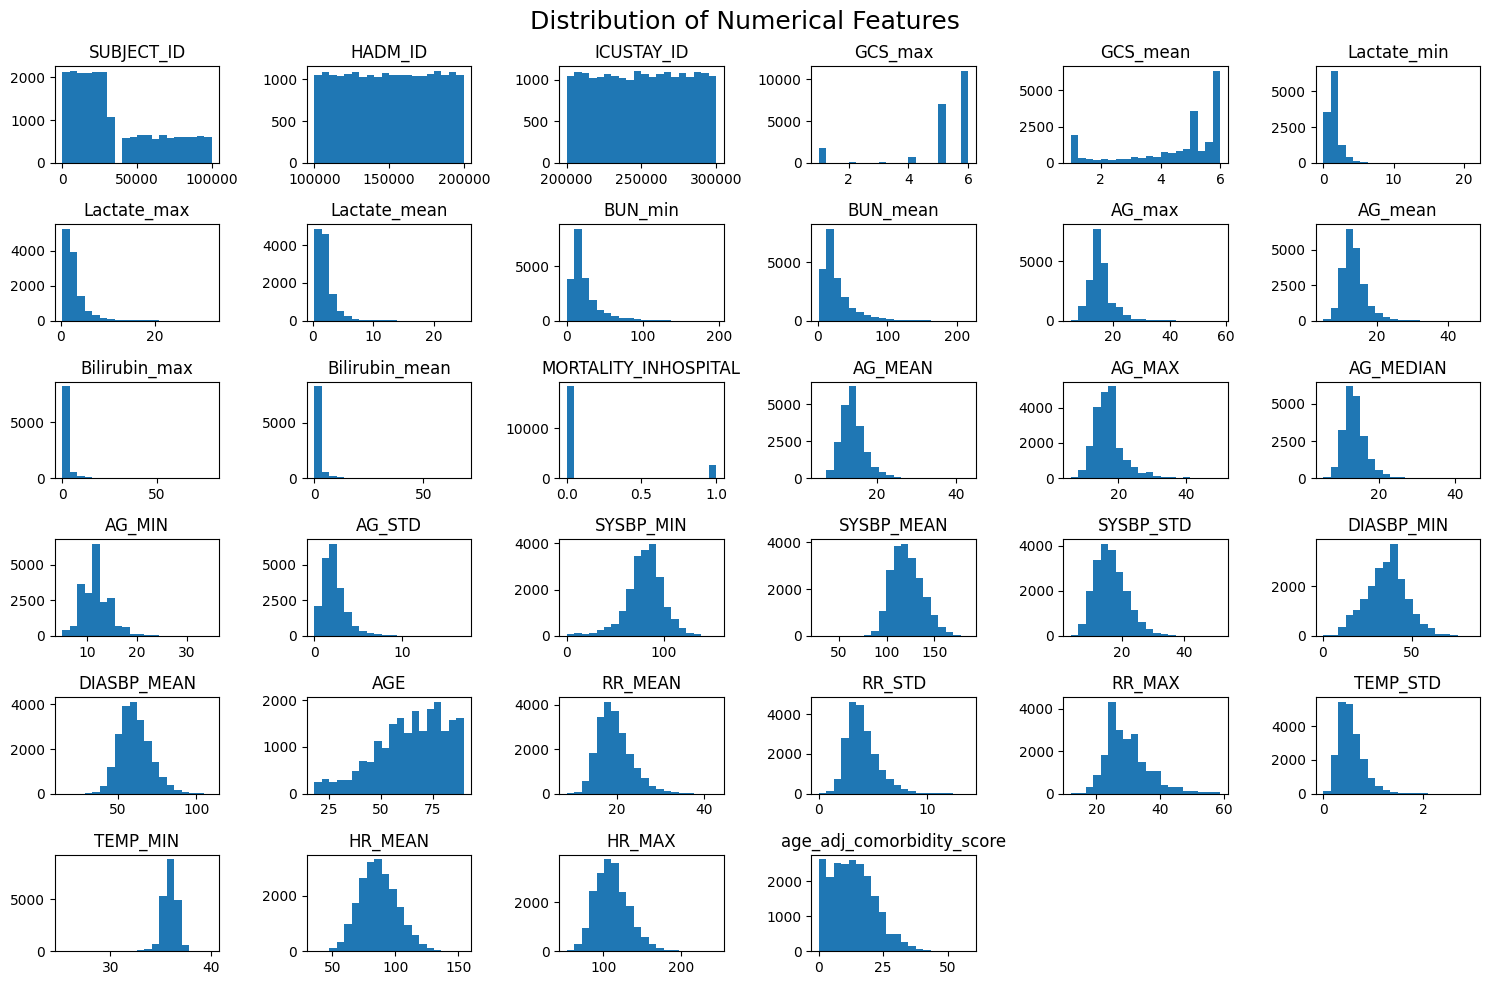

In [67]:
# Univariate Analysis 
df.hist(bins=20, figsize=(15, 10), grid=False)
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

In [68]:
# Calculate correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

                           SUBJECT_ID   HADM_ID  ICUSTAY_ID   GCS_max  \
SUBJECT_ID                   1.000000  0.017328    0.001473 -0.481498   
HADM_ID                      0.017328  1.000000   -0.002751 -0.005379   
ICUSTAY_ID                   0.001473 -0.002751    1.000000 -0.012372   
GCS_max                     -0.481498 -0.005379   -0.012372  1.000000   
GCS_mean                    -0.484551 -0.006291   -0.012566  0.837490   
Lactate_min                 -0.094316 -0.017985    0.004463  0.019481   
Lactate_max                 -0.056030 -0.004538    0.024412 -0.095327   
Lactate_mean                -0.075609 -0.009534    0.018717 -0.055528   
BUN_min                     -0.037293 -0.011020    0.005317 -0.015298   
BUN_mean                    -0.035032 -0.010307    0.004691 -0.022176   
AG_max                      -0.040374 -0.012405    0.011590 -0.060758   
AG_mean                     -0.068840 -0.014146    0.011130 -0.019658   
Bilirubin_max               -0.004472 -0.007118   -

In [69]:
# Split data
X = df.drop(['MORTALITY_INHOSPITAL', 'AG_max', 'AG_mean', 'SUBJECT_ID','HADM_ID','ICUSTAY_ID'], axis=1)
y = df['MORTALITY_INHOSPITAL']


X_full_train, X_test, y_full_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_full_train, y_full_train, test_size=0.2, random_state=42, stratify=y_full_train)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


# Filled the missing values with x_train median to avoid data leakage
medians = X_train.median()
X_train = X_train.fillna(medians)
X_val=X_val.fillna(medians)
X_test  = X_test.fillna(medians)







Train size: 13553
Test size: 4236


In [70]:
# Train the different model

model_lr= LogisticRegression(class_weight="balanced", max_iter=2000)
model_lr.fit(X_train, y_train)

model_dtc=DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, class_weight="balanced", random_state=42)
model_dtc.fit(X_train, y_train)

model_rfc= RandomForestClassifier(n_estimators=400,random_state=42,n_jobs=-1,class_weight="balanced_subsample")
model_rfc.fit(X_train, y_train)


def find_threshold_for_recall(model, X_val, y_val, target_recall=0.9):
    y_prob = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

    idx = np.where(recall >= target_recall)[0][-1]
    return thresholds[idx]



# Calculate thresholds for all models
print("Logistic Regression:")
threshold_lr = find_threshold_for_recall(model_lr, X_val, y_val)
print(threshold_lr)

print("DecisionTreeClassifier:")
threshold_dtc = find_threshold_for_recall(model_dtc, X_val, y_val)
print(threshold_dtc)

print("RandomForestClassifier:")
threshold_rfc = find_threshold_for_recall(model_rfc, X_val, y_val)
print(threshold_rfc)





Logistic Regression:
0.30925981995695023
DecisionTreeClassifier:
0.32450491643390433
RandomForestClassifier:
0.0825


In [71]:
# Calculate metrics for all models
def calculation(model, X_test, y_test, threshold):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    auroc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    cf_matrix = confusion_matrix(y_test, y_pred)
    cl_report = classification_report(y_test, y_pred, digits=4)
    return auroc, ap, cf_matrix, cl_report

# Calculate metrics for all models
print("Logistic Regression:")
auroc, ap, cf_matrix, cl_report = calculation(model_lr, X_test, y_test, threshold_lr )
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)

print("DecisionTreeClassifier:")
auroc, ap, cf_matrix, cl_report = calculation(model_dtc, X_test, y_test, threshold_dtc)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)

print("Random Forest:")
auroc, ap, cf_matrix, cl_report = calculation(model_rfc, X_test, y_test, threshold_rfc )
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)

Logistic Regression:
Area Under the Receiver Operating Characteristic curve:0.8579189069205347, Average Precision:0.5614444871554005
Confusion Matrix:
[[2304 1382]
 [  64  486]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9730    0.6251    0.7611      3686
           1     0.2602    0.8836    0.4020       550

    accuracy                         0.6586      4236
   macro avg     0.6166    0.7544    0.5816      4236
weighted avg     0.8804    0.6586    0.7145      4236

DecisionTreeClassifier:
Area Under the Receiver Operating Characteristic curve:0.8174690475016031, Average Precision:0.48146357670683926
Confusion Matrix:
[[1681 2005]
 [  53  497]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9694    0.4560    0.6203      3686
           1     0.1986    0.9036    0.3257       550

    accuracy                         0.5142      4236
   macro avg     0.5840    0.6798    0.4730      

In [72]:
# XGBoost model

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb=xgb.XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric=["auc", "aucpr"],
        random_state=42,
        n_jobs=-1)

model_xgb.fit(X_train, y_train)

#Find threshold fo XGBoost
print("XGBoost Classifier:")
threshold_xgb = find_threshold_for_recall(model_xgb, X_val, y_val)
print(threshold_xgb)

print("XGBoost Classifier:")
auroc, ap, cf_matrix, cl_report = calculation(model_xgb, X_test, y_test, threshold_xgb)
print(f"Area Under the Receiver Operating Characteristic curve:{auroc}, Average Precision:{ap}")
print('Confusion Matrix:')
print(cf_matrix)
print('Classification Report:')
print(cl_report)



XGBoost Classifier:
0.123544425
XGBoost Classifier:
Area Under the Receiver Operating Characteristic curve:0.8772554629309919, Average Precision:0.640443843204645
Confusion Matrix:
[[2517 1169]
 [  70  480]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9729    0.6829    0.8025      3686
           1     0.2911    0.8727    0.4366       550

    accuracy                         0.7075      4236
   macro avg     0.6320    0.7778    0.6195      4236
weighted avg     0.8844    0.7075    0.7550      4236



In [73]:
# With KFold cross validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"auroc": "roc_auc", "ap": "average_precision"}

def run_cv(name, model):
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    auroc_mean = res['test_auroc'].mean()
    auroc_std  = res['test_auroc'].std()
    ap_mean    = res['test_ap'].mean()
    ap_std     = res['test_ap'].std()

    print(f"{name} (5-Fold CV)")
    print(f"AUROC: {auroc_mean:.4f} ± {auroc_std:.4f}")
    print(f"AP: {ap_mean:.4f} ± {ap_std:.4f}\n")

    return {"model": name,"auroc_mean": auroc_mean, "auroc_std": auroc_std,"ap_mean": ap_mean, "ap_std": ap_std}

# Logistic Regression 
lr_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_lr)])

# Decision Tree
dtc_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_dtc)])

# Random Forest
rfc_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_rfc)])

# XGBoost model
xgb_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model_xgb)])

# Collecting results
results = []

results.append(run_cv("Logistic Regression", lr_pipe))
results.append(run_cv("Decision Tree", dtc_pipe))
results.append(run_cv("Random Forest", rfc_pipe))
results.append(run_cv("XGBoost", xgb_pipe))
print(results)

Logistic Regression (5-Fold CV)
AUROC: 0.8616 ± 0.0086
AP: 0.5452 ± 0.0202

Decision Tree (5-Fold CV)
AUROC: 0.8297 ± 0.0127
AP: 0.4736 ± 0.0332

Random Forest (5-Fold CV)
AUROC: 0.8774 ± 0.0090
AP: 0.5983 ± 0.0145

XGBoost (5-Fold CV)
AUROC: 0.8755 ± 0.0110
AP: 0.6148 ± 0.0221

[{'model': 'Logistic Regression', 'auroc_mean': np.float64(0.8615529594311424), 'auroc_std': np.float64(0.008601102299759652), 'ap_mean': np.float64(0.5451921250865495), 'ap_std': np.float64(0.02015708355739673)}, {'model': 'Decision Tree', 'auroc_mean': np.float64(0.8296579991366059), 'auroc_std': np.float64(0.012678158095333203), 'ap_mean': np.float64(0.4736049324998647), 'ap_std': np.float64(0.03320017232833962)}, {'model': 'Random Forest', 'auroc_mean': np.float64(0.8774045168354652), 'auroc_std': np.float64(0.0089554875202667), 'ap_mean': np.float64(0.5982977634812262), 'ap_std': np.float64(0.014517820427284821)}, {'model': 'XGBoost', 'auroc_mean': np.float64(0.8754580928247341), 'auroc_std': np.float64(0.

In [74]:
# Create dataframe of result
results_df = pd.DataFrame(results)
results_df

,model,auroc_mean,auroc_std,ap_mean,ap_std
0,Logistic Regression,0.861553,0.008601,0.545192,0.020157
1,Decision Tree,0.829658,0.012678,0.473605,0.033200
2,Random Forest,0.877405,0.008955,0.598298,0.014518
3,XGBoost,0.875458,0.010986,0.614795,0.022060


In [75]:
# Finding the best model
best_model = results_df.sort_values(by=["ap_mean", "auroc_mean"],ascending=False).iloc[0]

print("Selected model:", best_model["model"])

# pick the best pipeline object (not only name)
models = {
    "Logistic Regression": lr_pipe,
    "Decision Tree": dtc_pipe,
    "Random Forest": rfc_pipe,
    "XGBoost": xgb_pipe,
}

best_name = best_model["model"]
final_model = clone(models[best_name]) 
final_model.fit(X_train, y_train) 





Selected model: XGBoost


,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,objective,'binary:logistic'


In [76]:
# Evaluate on held-out test set
auroc, ap, cf_matrix, cl_report = calculation(final_model, X_test, y_test, threshold_xgb)
print(f"Final model (test) AUROC: {auroc:.4f}, AP: {ap:.4f}")
print("Confusion Matrix:")
print(cf_matrix)
print("Classification Report:")
print(cl_report)

Final model (test) AUROC: 0.8773, AP: 0.6404
Confusion Matrix:
[[2517 1169]
 [  70  480]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9729    0.6829    0.8025      3686
           1     0.2911    0.8727    0.4366       550

    accuracy                         0.7075      4236
   macro avg     0.6320    0.7778    0.6195      4236
weighted avg     0.8844    0.7075    0.7550      4236



                      feature  importance
14                  SYSBP_MIN    0.135448
0                     GCS_max    0.106921
27  age_adj_comorbidity_score    0.052599
1                    GCS_mean    0.045364
5                     BUN_min    0.034736
20                    RR_MEAN    0.034514
9                     AG_MEAN    0.033688
8              Bilirubin_mean    0.033221
6                    BUN_mean    0.032984
19                        AGE    0.030900
2                 Lactate_min    0.030865
17                 DIASBP_MIN    0.029871
15                 SYSBP_MEAN    0.029198
16                  SYSBP_STD    0.028899
11                  AG_MEDIAN    0.028110
10                     AG_MAX    0.027598
7               Bilirubin_max    0.026458
23                   TEMP_STD    0.026209
4                Lactate_mean    0.026087
25                    HR_MEAN    0.024990
24                   TEMP_MIN    0.024809
3                 Lactate_max    0.023621
18                DIASBP_MEAN    0

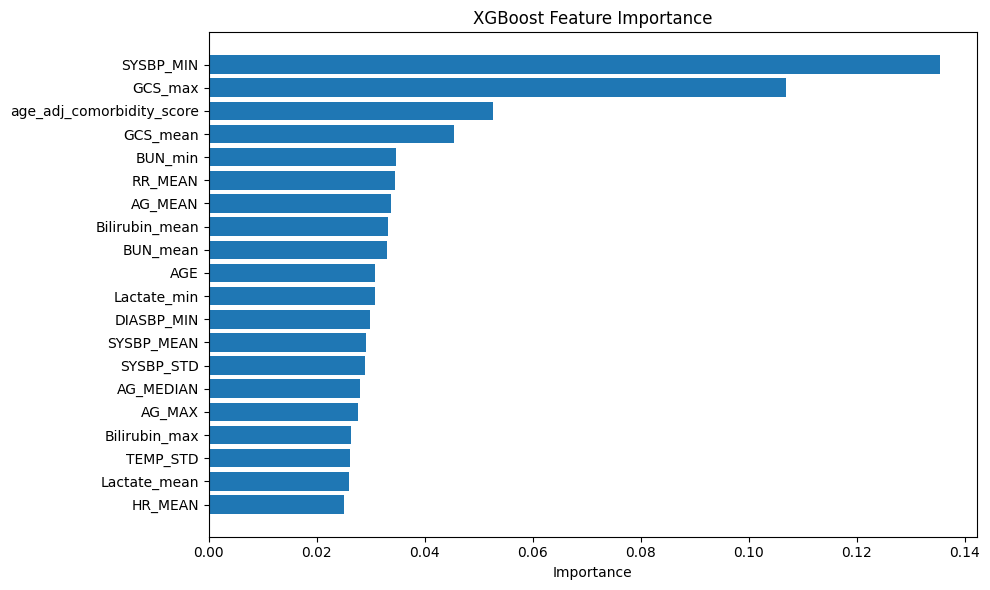

In [77]:
#Feature importance of XGBoost
xgb_fitted = final_model.named_steps["model"]

importance = xgb_fitted.feature_importances_


fi_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(fi_xgb)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(fi_xgb["feature"].head(20)[::-1],
         fi_xgb["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


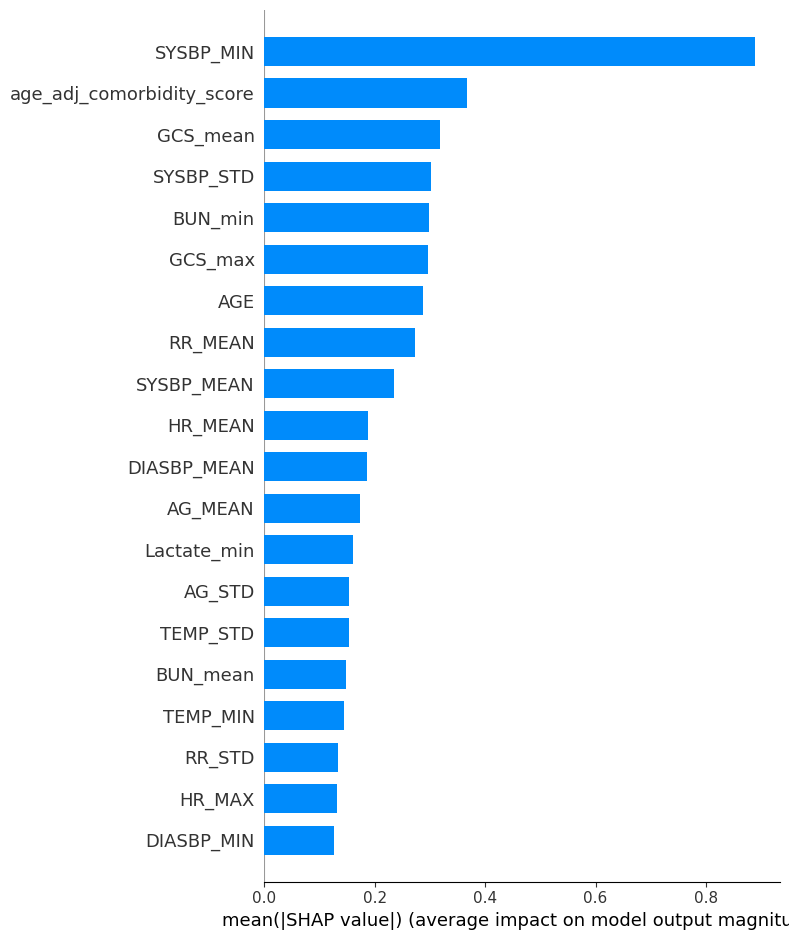

In [78]:
# SHAP summary plot showing global feature importance for the final XGBoost model

explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")

In [79]:
#pkl file of final model
with open('XGBoost.pkl', 'wb') as File:
    pickle.dump(final_model, File)